<a href="https://colab.research.google.com/github/vish970/-vish970-PRODIGY_DS_04/blob/main/Google_PlayStore_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

filename = next(iter(uploaded))
df = pd.read_csv(filename)

print("Dataset loaded successfully!")
print("Rows and Columns:", df.shape)

df.head()

Saving googleplaystore.csv to googleplaystore.csv
Dataset loaded successfully!
Rows and Columns: (10841, 13)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the already uploaded dataset
df = pd.read_csv("/content/googleplaystore.csv")

# Check dataset
print("Dataset loaded successfully!")
print("Rows and Columns:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

# Clean Reviews
df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")

# Clean Installs
df["Installs"] = df["Installs"].astype(str)
df["Installs"] = df["Installs"].str.replace("+", "", regex=False)
df["Installs"] = df["Installs"].str.replace(",", "", regex=False)
df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

# Clean Price
df["Price"] = df["Price"].astype(str)
df["Price"] = df["Price"].str.replace("$", "", regex=False)
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

# Convert date
df["Last Updated"] = pd.to_datetime(df["Last Updated"], errors="coerce")

# Fill missing ratings
df["Rating"] = df["Rating"].fillna(df["Rating"].mean())

print("\nData cleaning completed!")
print("\nFinal data information:")
df.info()

Dataset loaded successfully!
Rows and Columns: (10841, 13)

Column Names:
['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']

Missing Values:
App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

Duplicate Rows:
483

Data cleaning completed!

Final data information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             10841 non-null  object        
 1   Category        10841 non-null  object        
 2   Rating          10841 non-null  float64       
 3  

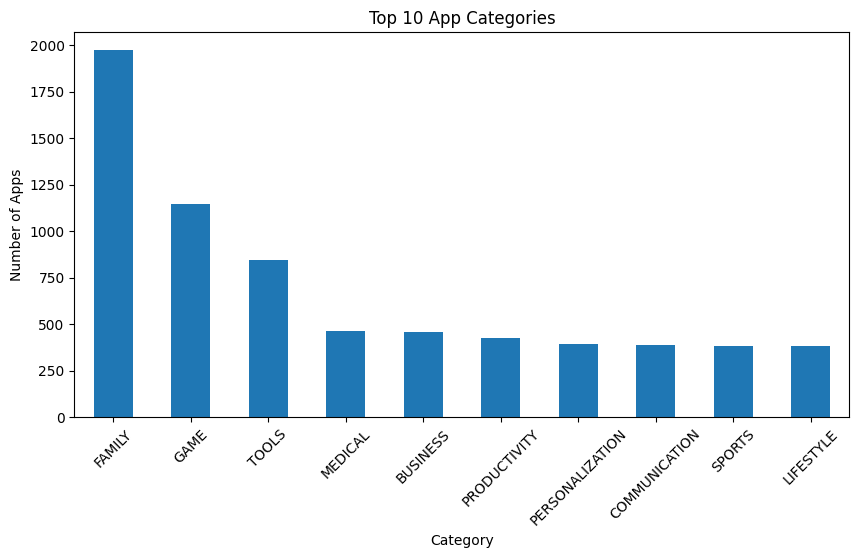

In [ ]:
plt.figure(figsize=(10,5))

df["Category"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 App Categories")
plt.xlabel("Category")
plt.ylabel("Number of Apps")
plt.xticks(rotation=45)
plt.show()

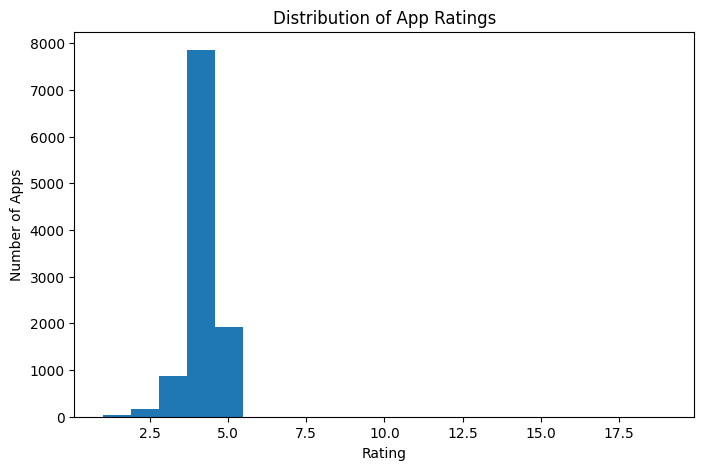

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df["Rating"], bins=20)

plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Apps")
plt.show()

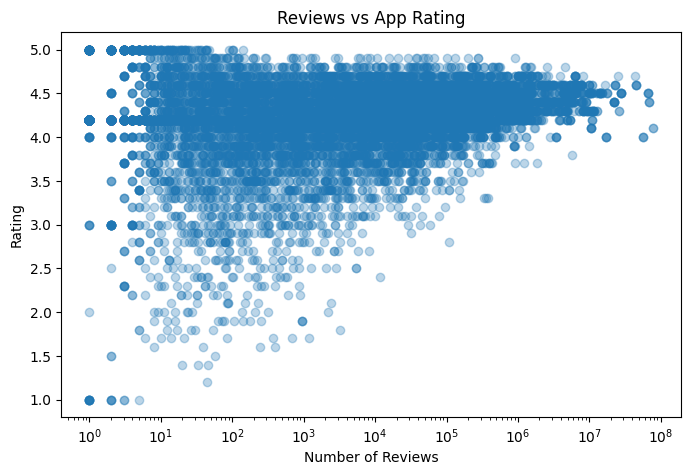

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(df["Reviews"], df["Rating"], alpha=0.3)

plt.title("Reviews vs App Rating")
plt.xlabel("Number of Reviews")
plt.ylabel("Rating")

plt.xscale("log")

plt.show()

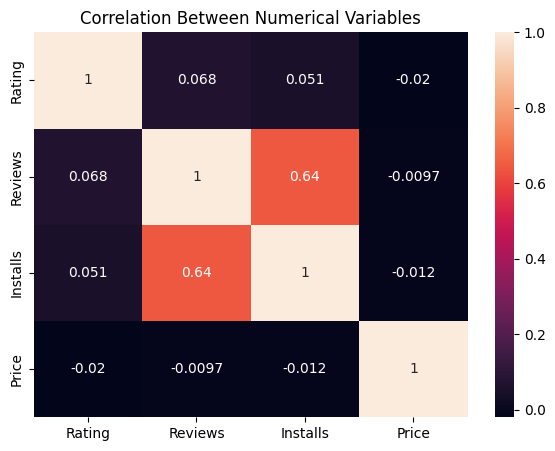

In [ ]:
plt.figure(figsize=(7,5))

correlation = df[["Rating", "Reviews", "Installs", "Price"]].corr()

sns.heatmap(correlation, annot=True)

plt.title("Correlation Between Numerical Variables")
plt.show()

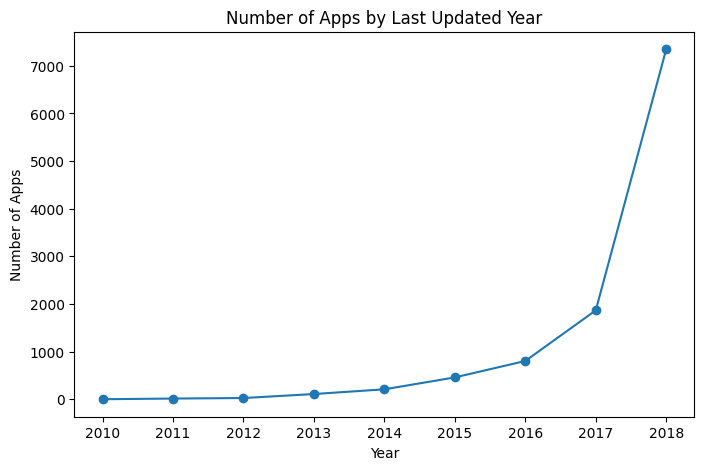

In [ ]:
df["Year"] = df["Last Updated"].dt.year

year_count = df["Year"].value_counts().sort_index()

plt.figure(figsize=(8,5))

plt.plot(year_count.index, year_count.values, marker="o")

plt.title("Number of Apps by Last Updated Year")
plt.xlabel("Year")
plt.ylabel("Number of Apps")

plt.show()

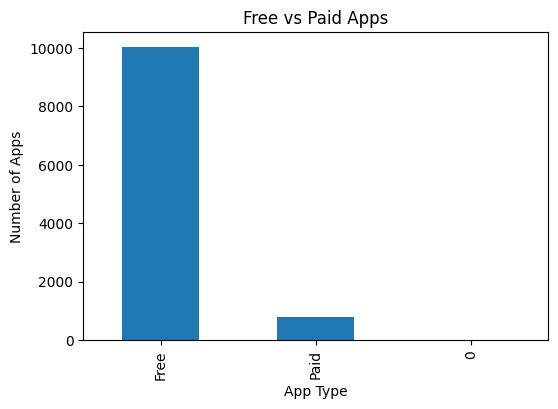

In [ ]:
plt.figure(figsize=(6,4))

df["Type"].value_counts().plot(kind="bar")

plt.title("Free vs Paid Apps")
plt.xlabel("App Type")
plt.ylabel("Number of Apps")

plt.show()

In [ ]:
print("===== KEY PERFORMANCE INDICATORS =====")

print("Total Apps:", df["App"].nunique())
print("Average Rating:", round(df["Rating"].mean(), 2))
print("Total Reviews:", int(df["Reviews"].sum()))
print("Total Installs:", int(df["Installs"].sum()))

===== KEY PERFORMANCE INDICATORS =====
Total Apps: 9660
Average Rating: 4.19
Total Reviews: 4814617393
Total Installs: 167633433487


In [ ]:
df.to_csv("googleplaystore_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [ ]:
from google.colab import files

files.download("googleplaystore_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
1. Interpretation of Visualizations
1. Top 10 App Categories

The bar chart shows the categories with the highest number
 of apps on the Google Play Store. Some categories contain considerably more
 apps than others,
  indicating that app availability is concentrated in a few major categories.

2. Rating Distribution

The rating distribution shows that most apps have ratings concentrated
around the higher range.
This indicates that a large proportion of the available apps received relatively
positive user ratings.

3. Reviews vs Rating

The scatter plot shows the relationship between the number of reviews and
app ratings.
The points are widely distributed, indicating that having a large number of
reviews does not necessarily result in a higher rating.

4. Correlation Heatmap

The correlation heatmap shows the relationships between numerical variables
such as Rating, Reviews, Installs and Price. Reviews and Installs show a
positive relationship because apps with more users generally tend to receive
more reviews.

5. Apps by Last Updated Year

The chart shows the number of apps according to their last updated year.
It indicates that many apps were updated in the more recent years represented
 in the dataset, showing continued maintenance and development of apps.

6. Free vs Paid Apps

The chart compares free and paid applications. Free apps make up the large
majority of the dataset, while paid applications represent a much smaller portion.
This indicates that the free-to-download model is much more common in the Google
Play Store dataset.

In [ ]:
2. Five Key Insights

Insight 1: Inapp categories are unevenly distributed

Some categories contain substantially more apps than other categories,
implying developers are concentrated in specific app categories.

Insight 2: Overall, most apps have relatively high ratings

The rating distribution is heavily skewed towards the upper end.

Insight 3: Number of reviews and installs are related

As anticipated, number of reviews is positively associated with the number of
installs. The more people are using an application, the more chances there are
 for individuals to write a review.

Insight 4: Majority of apps are free

There is a significantly higher number of free applications compared to paid
applications. There is a clear preference for free downloads in the analyzed
data set.

Insight 5: Many apps were last updated recently

There is a significant portion of apps that were updated in the recent year.
This implies that application developers continue to frequently update their
products.

In [ ]:
Conclusion:
I have completed my analysis of the Google Play Store dataset.
The dataset contains information on app categories, ratings, reviews,
installations, prices, and updates. The graphs and KPI analysis that I have
made using the data helped me discover essential insights about the dataset.
Python is a helpful language for data cleaning
and exploratory data analysis, whereas Tableau will assist me in building a
dashboard to display the results of my analysis.